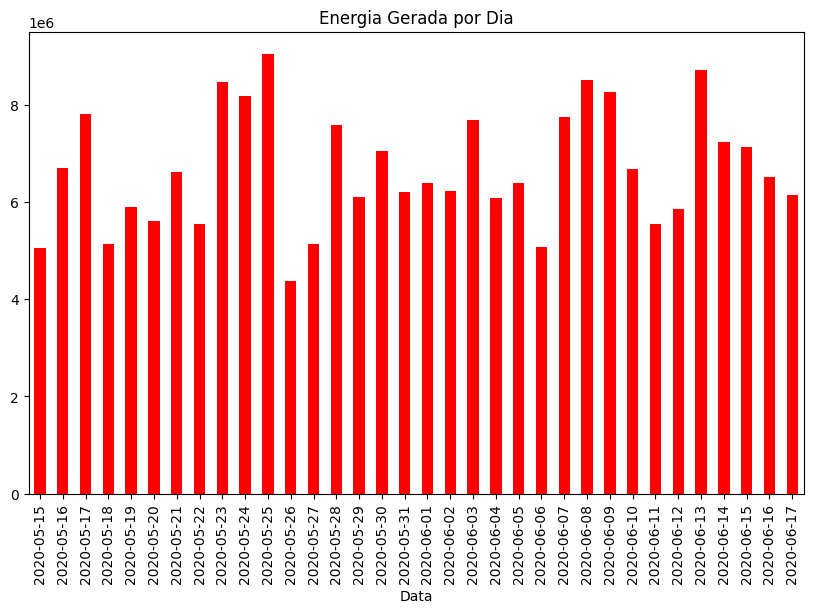

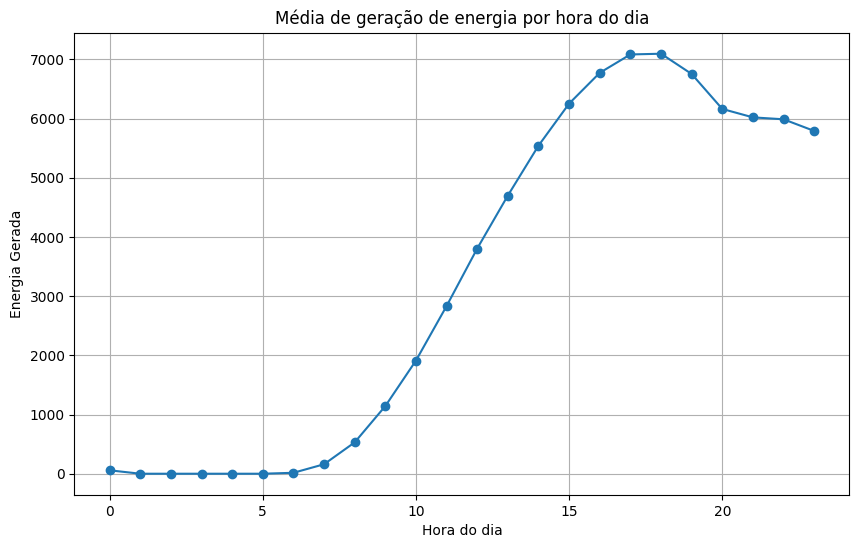

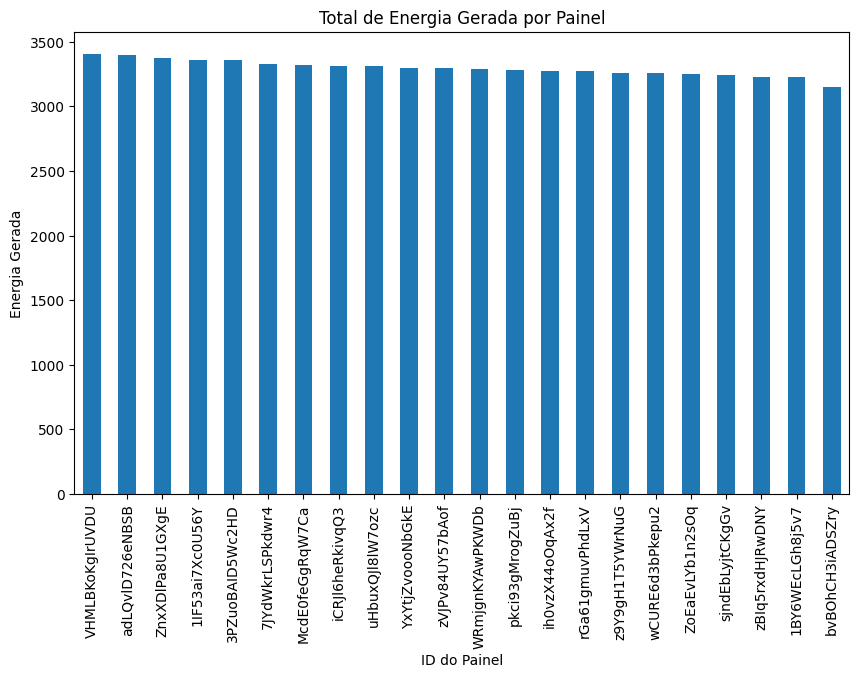

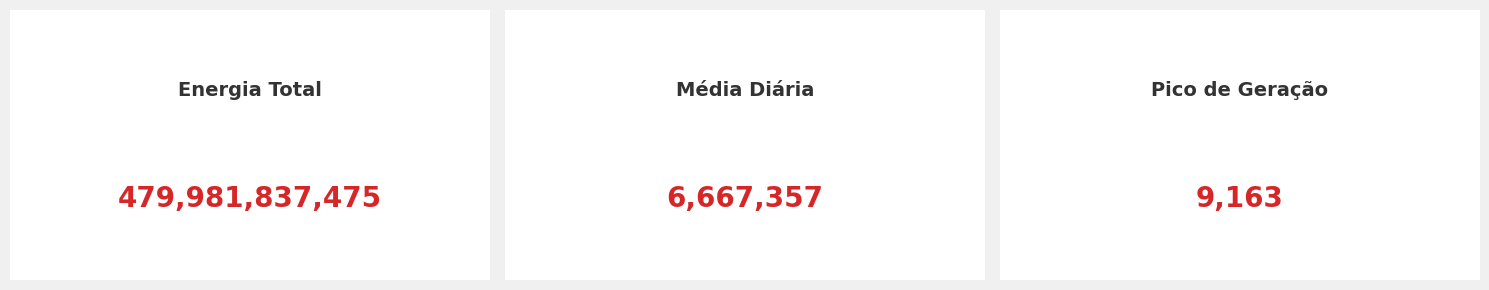

In [87]:
# Importação de bibliotecas e arquivos
import matplotlib.pyplot as plt
import pandas as pd
df = pd.read_csv('/content/Plant_1_Generation_Data.csv')

# Limpeza e organização de dados
df.rename(columns={'SOURCE_KEY':'ID do Painel'}, inplace=True)
df.rename(columns={'DC_POWER':'Corrente C'}, inplace=True)
df.rename(columns={'AC_POWER':'Corrente A'}, inplace=True)
df.rename(columns={'DAILY_YIELD':'Energia Gerada'}, inplace=True)
df.rename(columns={'TOTAL_YIELD':'Energia Total'}, inplace=True)
df = df.drop(columns=['PLANT_ID'])

# Conversão de datas e horas
df['DATE_TIME'] = pd.to_datetime(df['DATE_TIME'], format='%d-%m-%Y %H:%M')
df['Data'] = df['DATE_TIME'].dt.date
df['Hora_Num'] = df['DATE_TIME'].dt.hour
df = df.drop(columns=['DATE_TIME'])

### Analise dos dados

# Energia gerada por dia
plt.figure(figsize=(10, 6))
df.groupby('Data')['Energia Gerada'].sum().plot(kind='bar', color='red')
plt.title('Energia Gerada por Dia')
plt.show()

# Energia gerada por hora
plt.figure(figsize=(10, 6))
df.groupby('Hora_Num')['Energia Gerada'].mean().plot(marker='o')
plt.title('Média de geração de energia por hora do dia')
plt.xlabel('Hora do dia')
plt.ylabel('Energia Gerada')
plt.grid(True)
plt.show()

# Painel que mais gerou
plt.figure(figsize=(10, 6))
df.groupby('ID do Painel')['Energia Gerada'].mean().sort_values(ascending=False).plot(kind='bar')
plt.title('Total de Energia Gerada por Painel')
plt.xlabel('ID do Painel')
plt.ylabel('Energia Gerada')
plt.show()

# Criando as KPIs
fig, axs = plt.subplots(1, 3, figsize=(15, 3))
fig.patch.set_facecolor('#f0f0f0')

kpis = [
    ('Energia Total', f'{energia_total:,.0f}'),
    ('Média Diária', f'{media_diaria:,.0f}'),
    ('Pico de Geração', f'{max_energia_gerada:,.0f}')
]

for kp, (label, value) in enumerate(kpis):
    axs[kp].text(0.5, 0.7, label, fontsize=14, ha='center', va='center', fontweight='bold', color='#333333')
    axs[kp].text(0.5, 0.3, value, fontsize=20, ha='center', va='center', fontweight='bold', color='#d62728')
    axs[kp].set_xticks([])
    axs[kp].set_yticks([])
    axs[kp].spines['top'].set_visible(False)
    axs[kp].spines['right'].set_visible(False)
    axs[kp].spines['left'].set_visible(False)
    axs[kp].spines['bottom'].set_visible(False)
    axs[kp].set_facecolor('white')

plt.tight_layout()
plt.show()